# Task 8 目标检测练习 (小组)

## 陈璐 胡心怡 张诗函 徐雅琪 朱怡锦 蒋尚言 欧阳雯茜

### 尝试使用PyTorch实现对视频进行目标检测案例，具体要求如下：【1】代码应包含完整的流程，包括切分视频；标注数据展示；模型训练；模型检测；最终的视频合成。【1.1】拍摄视频时长应不短于120秒（10分）；【1.2】视频中的目标应频繁出现，且进行检测的物体类别不得少于3类，标注图片不得少于400张（20分）；【1.3】对标注数据进行可视化展示（10分）；【1.4】训练YoLo模型，可以参照示例代码，也可以寻找最新的YoLo关于PyTorch的接口(20分)；【1.5】利用训练好的模型进行检测，并将检测结果合成为新的视频（30分）；【2】利用训练进行适当的文字说明，报告的美观程度 (10分) ；

### 第一步：切分视频

In [9]:
import cv2
import os
import zipfile
import shutil
# 创建文件夹储存切分图片
if not os.path.exists('./images_training/'):
    os.makedirs('./images_training/')

# 读取视频并切分
vc = cv2.VideoCapture('test.mp4')

# 查看视频 fps
fps = vc.get(cv2.CAP_PROP_FPS)
print('视频FPS =', fps)

i = 0 # i: 视频总帧数计数器
save_id = 0 # save_id: 已保存图片的编号（从0开始）
rval = True # rval: 读取帧的状态标志，True表示成功读取
interval = 7 # 切分间隔，每 7 帧保存 1 张

# 逐帧读取视频
while True:
    # 每读取100帧，打印一次进度
    if (i + 1) % 100 == 0:
        print(i + 1)

    # 读取一帧：rval为布尔值，frame为图像数据
    rval, frame = vc.read()

    if rval == True:
        # 判断当前帧序号是否为间隔的整数倍（即每7帧保存1张）
        if (i + 1) % interval == 0:
            # 保存图片到images_training文件夹并编号
            cv2.imwrite('./images_training/{:04d}.jpg'.format(save_id + 1), frame)
            save_id = save_id + 1

        i = i + 1
        cv2.waitKey(1)
    else:
        break
        
# 释放VideoCapture对象占用的资源
vc.release()

视频FPS = 24.85996705107084
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000


In [58]:
# 查看切分结果
l = os.listdir('./images_training/')
print('共切分出 {} 张图片'.format(len(l)))

共切分出 430 张图片


### 第二步：图片标注
#### 使用LabelImg对第一步切出的430张图片进行标注
#### 标注数据大致按照8:2切分为训练集（344张）和验证集（86张）

### 第三步：数据展示

In [10]:
import cv2
import matplotlib.pyplot as plt
import os

# 展示数据目录结构
print(os.listdir("video_yolo_project/dataset"))
print(os.listdir("video_yolo_project/dataset/images"))
print(os.listdir("video_yolo_project/dataset/labels"))

['images', 'labels']
['train', 'val']
['train', 'val']


标签内容（类别 x_center y_center width height）:
0 0.900781 0.715972 0.126562 0.423611
1 0.354297 0.520139 0.146094 0.090278
1 0.096875 0.515972 0.187500 0.112500
4 0.350391 0.397917 0.030469 0.068056
4 0.410156 0.382639 0.026562 0.093056

图片尺寸: 1280 x 720


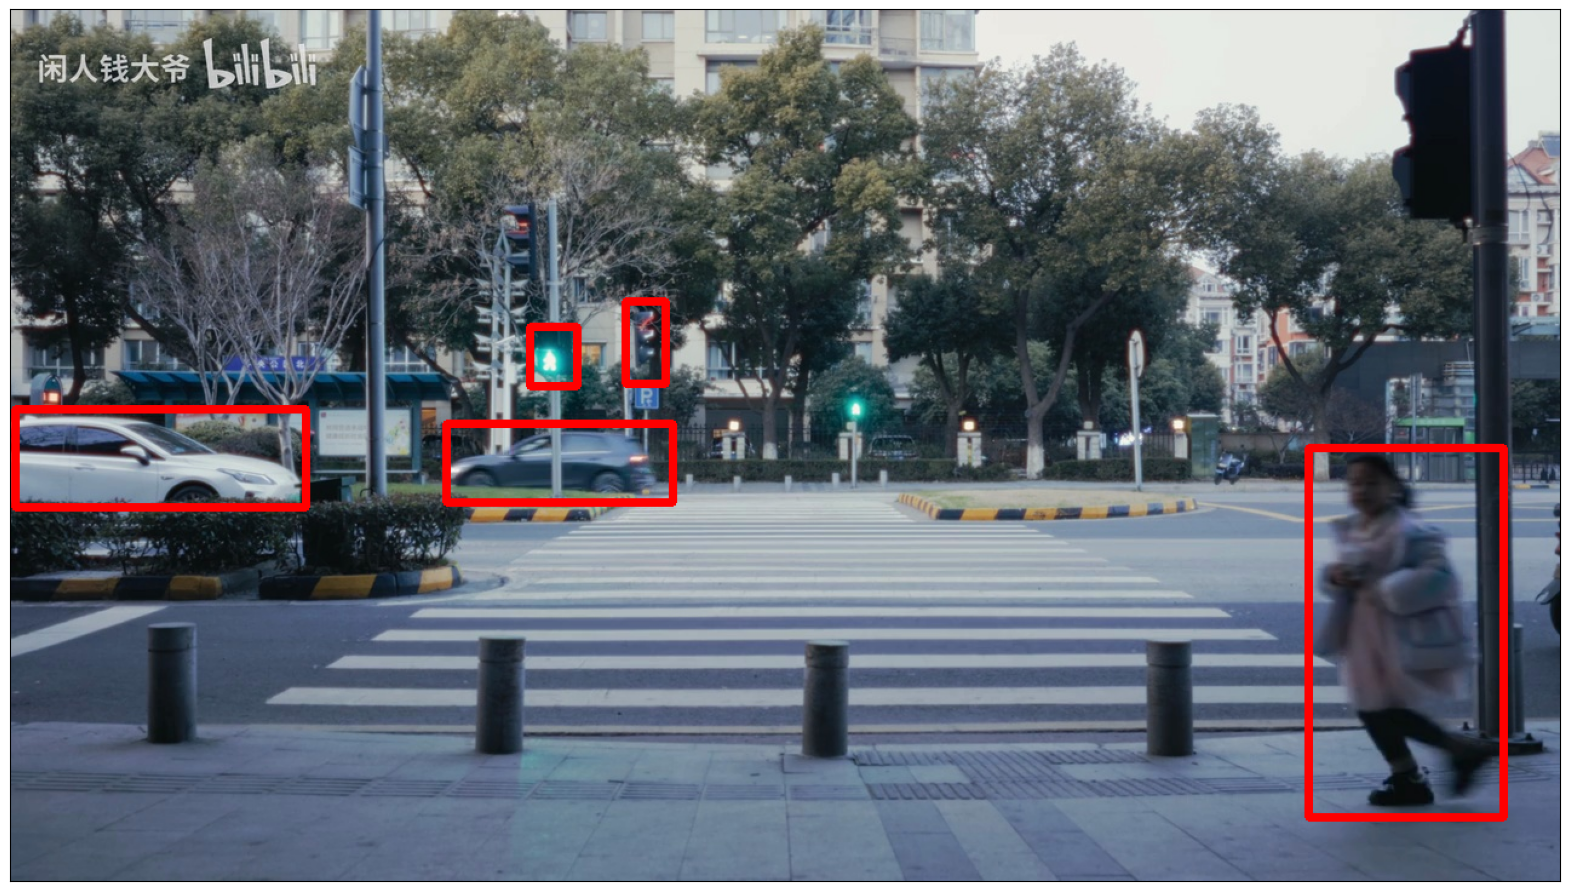


成功展示图片，共绘制了 5 个边界框


In [59]:
import cv2
import matplotlib.pyplot as plt
import os
# 设置文件路径
label_path = "video_yolo_project/dataset/labels/train/0001.txt"
image_path = "video_yolo_project/dataset/images/train/0001.jpg"

# 读取标签文件
f = open(label_path, 'r')
# 逐行读入文本
lines = f.readlines()
f.close()

# 输出标签内容
print("标签内容（类别 x_center y_center width height）:")
for line in lines:
    print(line.strip())

# 读取图片
trainpic = cv2.imread(image_path)
h, w = trainpic.shape[:2]  # 获取图片高度和宽度

print(f"\n图片尺寸: {w} x {h}")

# 设置图形大小
plt.figure(figsize=(20, 15))

# 解析每一行标签并绘制边界框
for line in lines:
    msg = line.strip().split() # 将这一行的标签分成坐标点
    
    # 将YOLO格式转换为像素坐标
    x1 = int((float(msg[1]) - float(msg[3]) / 2) * w) # x轴中心 - 宽度 / 2
    y1 = int((float(msg[2]) - float(msg[4]) / 2) * h) # y轴中心 - 高度 / 2
    x2 = int((float(msg[1]) + float(msg[3]) / 2) * w) # x轴中心 + 宽度 / 2
    y2 = int((float(msg[2]) + float(msg[4]) / 2) * h) # y轴中心 + 高度 / 2
    
    # 绘制矩形框（红色，线宽5像素）
    cv2.rectangle(trainpic, (x1, y1), (x2, y2), (0, 0, 255), 5)

# OpenCV使用BGR，matplotlib使用RGB，需要转换颜色通道
b, g, r = cv2.split(trainpic)
trainpic_plt = cv2.merge([r, g, b])

# 显示图片
plt.xticks([]), plt.yticks([])  # 隐藏坐标轴
plt.imshow(trainpic_plt)
plt.show()

print(f"\n成功展示图片，共绘制了 {len(lines)} 个边界框")

### 第六步：将预测结果合成视频

In [ ]:
import cv2
import numpy as np

# 建立类别字典
label_dict = {
    '0': 'person',
    '1': 'car',
    '2': 'motorcycle',
    '3': 'bicycle',
    '4': 'traffic_light'
}
# 读取原始视频
cap = cv2.VideoCapture('yolo.mp4') 
# 遍历帧的原始变量
i = 0

# 设置VideoWriter，严格使用原视频的FPS和宽高来保证视频不失真
writer = cv2.VideoWriter(
    'output_test.avi',
    cv2.VideoWriter_fourcc(*'XVID'), 
    cap.get(cv2.CAP_PROP_FPS),
    (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
)

# 逐帧处理视频
while True:
    ret, frame = cap.read() # 读入这一帧的图像
    if not ret:
        break # 视频读取完毕
        
    i += 1
    
    # 匹配对应的检测结果文件
    # YOLO 视频检测输出的标签通常命名为：视频名_帧号.txt
    video_base_name = os.path.splitext(os.path.basename(video_path))[0]
    label_file = os.path.join(labels_dir, f"{video_base_name}_{i}.txt")
    
    try:
        with open(label_file, "r", encoding="utf-8") as f:
            lines = f.readlines() 
            for line in lines:
                msg = line.strip().split() 
                if not msg: continue
                
                # 核心：坐标转换逻辑（将归一化比例还原为像素坐标） 
                cls_id = msg[0]
                xc, yc = float(msg[1]), float(msg[2])
                bw, bh = float(msg[3]), float(msg[4])
                
                # 根据课件公式计算矩形框的四个顶点坐标 
                x1 = int((xc - bw/2) * w) # 左上角 x 
                y1 = int((yc - bh/2) * h) # 左上角 y 
                x2 = int((xc + bw/2) * w) # 右下角 x 
                y2 = int((yc + bh/2) * h) # 右下角 y 
                
                # 绘图：在帧上画框并添加类别文字 
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 3) 
                
                label_text = label_dict.get(cls_id, "unknown")
                # 在框的左上方写上类别名称 
                cv2.putText(frame, label_text, (x1, y1 - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                            
    except FileNotFoundError:
        # 如果该帧没有检测到任何目标，或者 labels 文件夹中没有该文件，则直接跳过 [cite: 1676-1677]
        pass
    
    # 将处理后的帧写入新的视频文件
    writer.write(frame)

# 释放资源 (如果不释放，会导致生成的视频文件损坏无法播放)
cap.release()
writer.release()
print(f"测试视频已生成，共处理了 {i} 帧。")